# Customer Churn Prediction: A Complete ML Walkthrough

**What we're building:** A model that predicts whether a telecom customer will cancel their service ("churn").

**Why this problem?** Acquiring a new customer costs 5–25x more than retaining an existing one. If a company can predict *who* is about to leave, they can intervene with a retention offer. That's real business value.

**What you'll learn:**
1. How to explore and understand data before touching any models
2. Why cleaning data matters more than picking the right algorithm
3. How three different models think about the same problem
4. Why accuracy is a misleading metric for imbalanced problems like churn
5. How to interpret *why* a model makes its predictions

---

## The Big Picture: What is Machine Learning, Actually?

Traditional programming: you write rules → computer follows them.

Machine learning: you show examples (data) → the algorithm *learns* the rules itself.

For churn prediction:
- **Input (features):** customer's contract type, monthly charges, how long they've been a customer, etc.
- **Output (label/target):** Did they churn? (Yes/No)
- **The model:** learns patterns like "customers on month-to-month contracts who pay a lot tend to leave"

This is called **supervised learning** — we have labeled historical data (we know who churned) and we're teaching the model from it.

---
## Step 1: Setup — Import Tools

Before cooking, you gather your tools. In Python/ML, those are libraries.

Think of each library as a specialist:
- **pandas** — spreadsheet expert (loads, cleans, manipulates data)
- **numpy** — math expert (numbers, arrays, calculations)
- **matplotlib / seaborn** — visualization experts (charts and graphs)
- **scikit-learn** — the core ML toolkit (models, preprocessing, evaluation)
- **xgboost** — a powerful gradient boosting model
- **shap** — explains *why* a model made a prediction

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# Scikit-learn: evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# Model interpretation
import shap

# Make charts look nice
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

# Suppress minor warnings so output stays clean
import warnings
warnings.filterwarnings('ignore')

print('All imports successful!')

All imports successful!


/home/blakefurn/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Step 2: Load the Data

We're using the **IBM Telco Customer Churn** dataset — a classic benchmark dataset that's freely available online. It contains ~7,000 customers with 20 features about their service plan, and whether they churned.

We'll download it directly from a public URL so you don't need a Kaggle account.

In [2]:
# Load the dataset from a public GitHub mirror of the IBM dataset
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'

df = pd.read_csv(url)

print(f'Dataset shape: {df.shape}')  # (rows, columns)
print(f'That means: {df.shape[0]} customers, {df.shape[1]} columns')

Dataset shape: (7043, 21)
That means: 7043 customers, 21 columns


In [3]:
# Look at the first 5 rows — get a feel for what we're working with
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Column names and data types
# 'object' = text/categorical, 'int64'/'float64' = numbers
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**What we just saw:**
- `customerID` — just an ID, useless for prediction
- `gender`, `Partner`, `Dependents` — demographic info
- `tenure` — months the customer has been with the company
- `PhoneService`, `InternetService`, `Contract`, etc. — what services they subscribe to
- `MonthlyCharges`, `TotalCharges` — billing info
- **`Churn`** — our **target variable** (what we want to predict)

---
## Step 3: Exploratory Data Analysis (EDA)

EDA = "Look before you leap."

Before touching any ML algorithm, you need to *understand* your data:
- What does the target variable look like? (Is it balanced?)
- Are there missing values?
- What are the distributions of key features?
- Which features seem related to churn?

Skipping EDA is the #1 mistake beginners make. A model trained on bad or misunderstood data will give you bad predictions — it just won't tell you why.

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


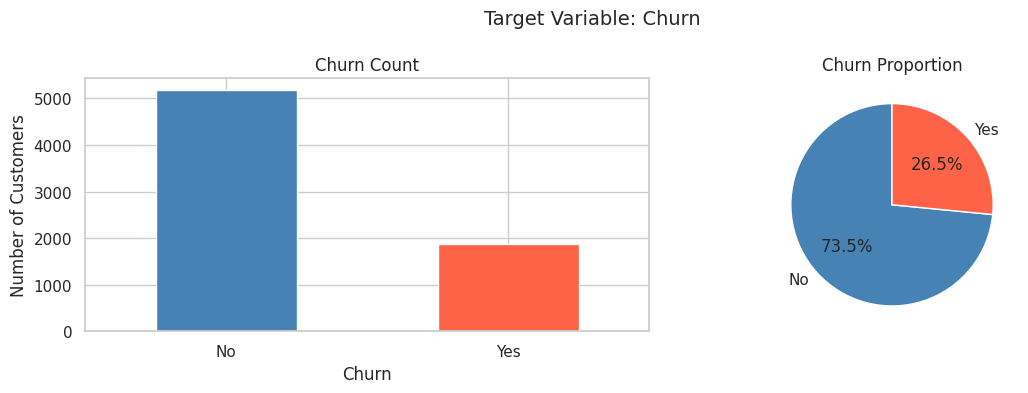

In [5]:
# === Target Variable Distribution ===
# How many customers churned vs. stayed?
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Churn counts:')
print(churn_counts)
print('\nChurn percentages:')
print(churn_pct.round(1))

# Plot it
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], rot=0)
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Number of Customers')

axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Churn Proportion')

plt.suptitle('Target Variable: Churn', fontsize=14)
plt.tight_layout()
plt.show()

**Key insight: Class Imbalance**

About 73% of customers did NOT churn, and 27% did. This is an **imbalanced dataset**.

Why does this matter? Imagine a lazy model that just predicts "No churn" for everyone. It would be *73% accurate* — but completely useless! It would miss every single churner.

This is why we won't use accuracy as our main metric. We'll use **precision, recall, F1, and AUC-ROC** instead (explained later).

In [6]:
# === Missing Values ===
# Missing data = holes in your training examples. Models can't learn from gaps.
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values!')

Missing values per column:
No missing values!


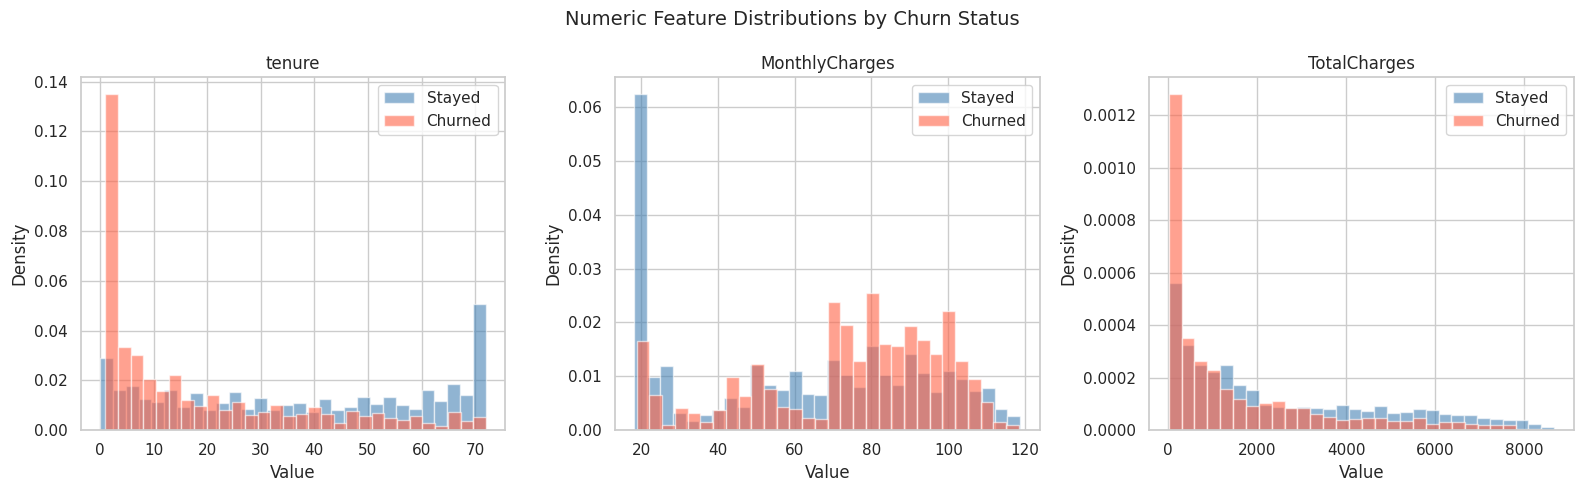

In [7]:
# === Numeric Feature Distributions ===
# The three numeric features: tenure, MonthlyCharges, TotalCharges
# We split by churn to see if distributions differ between churners and non-churners

# First, we need to fix TotalCharges — it was loaded as text despite being a number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(numeric_cols):
    for churn_val, color, label in [('No', 'steelblue', 'Stayed'), ('Yes', 'tomato', 'Churned')]:
        subset = df[df['Churn'] == churn_val][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Numeric Feature Distributions by Churn Status', fontsize=14)
plt.tight_layout()
plt.show()

**What the histograms tell us:**

- **tenure:** Churners tend to leave *early* — there's a spike at low tenure values for the red (churned) group. Long-tenured customers rarely leave.
- **MonthlyCharges:** Churners tend to pay *more* per month. High bill → higher churn risk.
- **TotalCharges:** Correlated with tenure (longer customers = higher total charges), so the pattern is mixed.

These visual patterns are exactly what a model will learn to detect automatically.

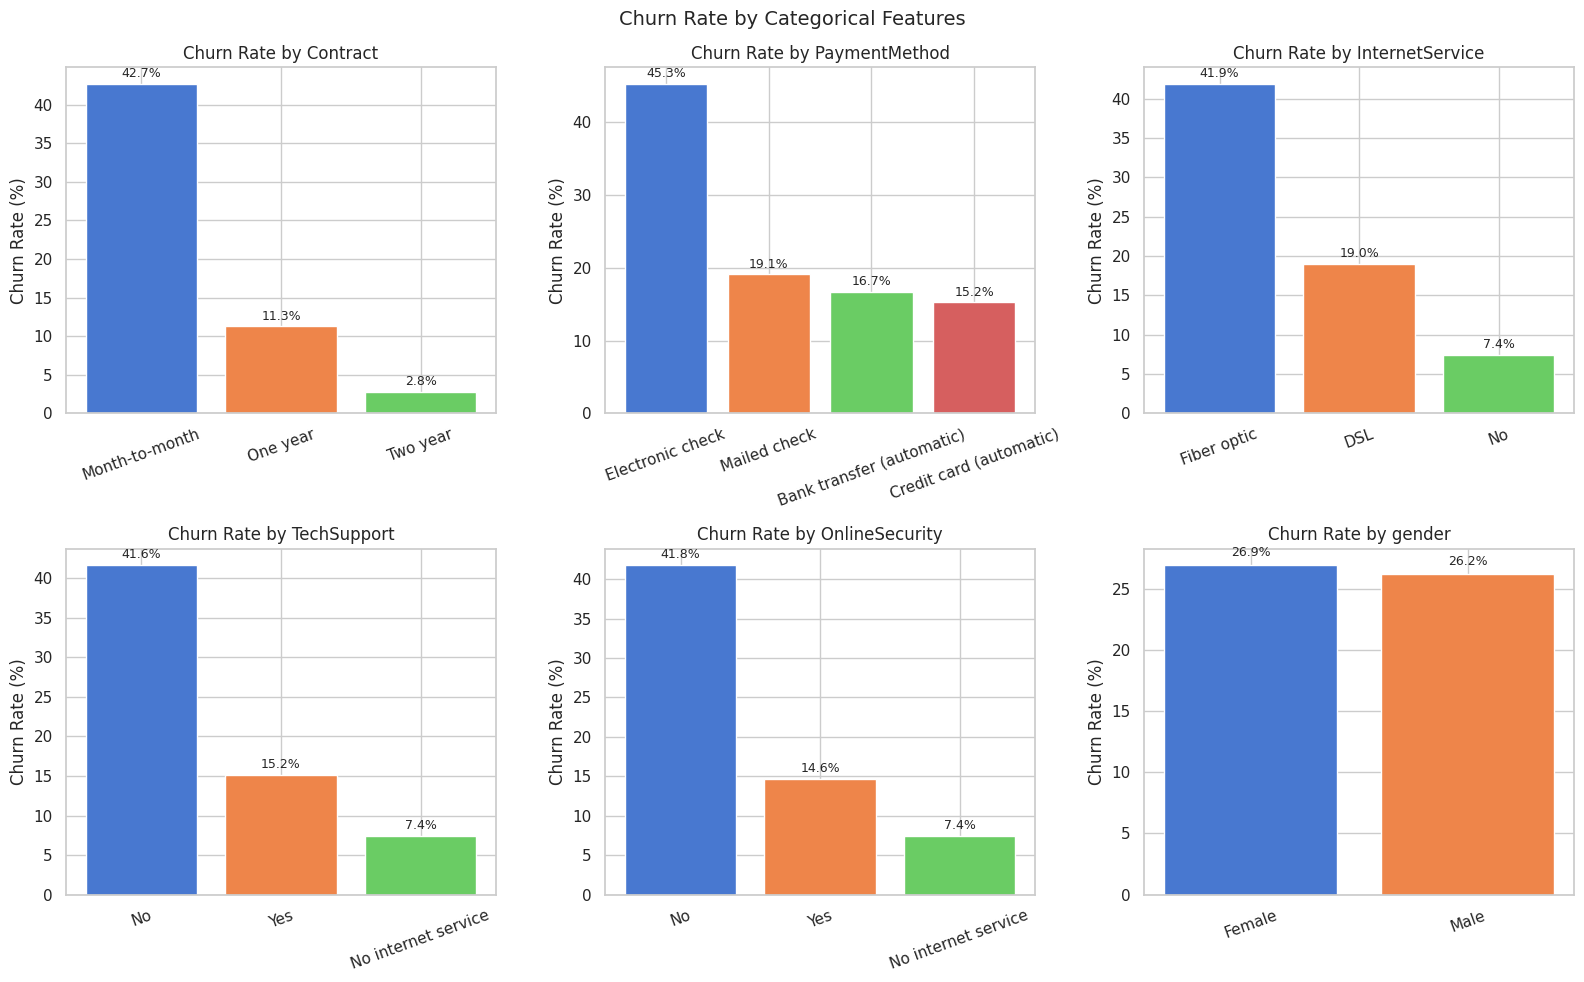

In [8]:
# === Categorical Feature Analysis ===
# For each category, what % of customers in that group churned?

# The most business-relevant categorical features
cat_features = ['Contract', 'PaymentMethod', 'InternetService', 
                'TechSupport', 'OnlineSecurity', 'gender']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)
    
    bars = axes[i].bar(churn_rate.index, churn_rate.values, 
                       color=sns.color_palette('muted', len(churn_rate)))
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)
    
    # Add value labels on bars
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14)
plt.tight_layout()
plt.show()

**Huge insights from these charts:**

- **Contract type** is the biggest predictor: month-to-month customers churn at ~43%! Two-year contract customers: only ~3%.
- **No tech support / no online security** = higher churn. Customers who feel unsupported leave.
- **Electronic check payment** correlates with high churn — possibly a demographic signal.
- **Fiber optic internet** customers churn more than DSL — possibly due to pricing.
- **Gender** shows almost no difference — gender is likely not a useful predictor.

This kind of analysis guides feature engineering decisions.

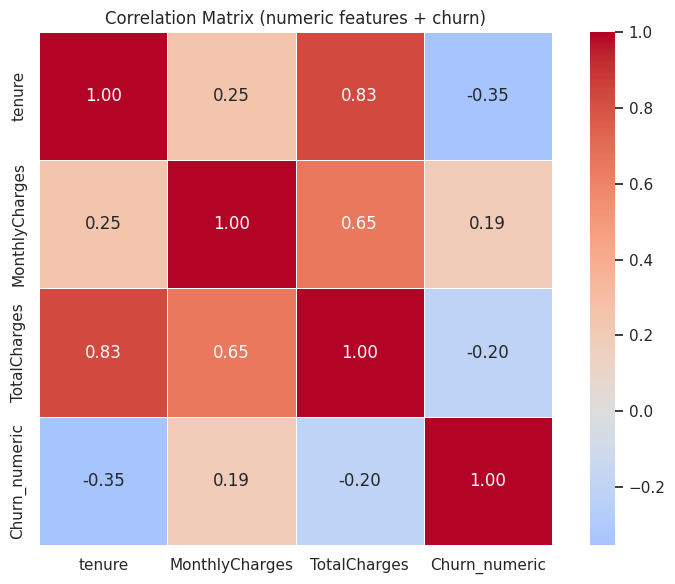

In [9]:
# === Correlation Heatmap for Numeric Features ===
# Correlation measures how much two variables move together (-1 to +1)
# We'll add a numeric version of Churn (1=churned, 0=stayed) for this

df['Churn_numeric'] = (df['Churn'] == 'Yes').astype(int)

corr_matrix = df[numeric_cols + ['Churn_numeric']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix (numeric features + churn)')
plt.tight_layout()
plt.show()

**Reading the heatmap:**
- The `Churn_numeric` row/column shows each feature's correlation with churn.
- `tenure` has a **negative** correlation with churn (−0.35) — longer tenure = less likely to churn.
- `MonthlyCharges` has a **positive** correlation (+0.19) — higher bills = more likely to churn.
- `tenure` and `TotalCharges` are highly correlated (0.83) — multicollinearity. This can cause issues for some models (especially Logistic Regression).

---
## Step 4: Data Cleaning & Preprocessing

Raw data is rarely model-ready. We need to:
1. Handle missing values
2. Remove irrelevant columns
3. Convert text categories into numbers (models only understand numbers)
4. Scale numeric features so they're on the same playing field

**Why do models need numbers?** Algorithms perform mathematical operations — addition, multiplication — which only work on numbers. "Yes" and "No" mean nothing to a matrix multiplication.

In [10]:
# Make a clean copy so we always have the original
data = df.copy()

# --- 1. Drop useless columns ---
# customerID is just an identifier — it has no predictive power
# Churn_numeric is redundant with Churn (we'll use Churn as our target)
data = data.drop(columns=['customerID', 'Churn_numeric'])

# --- 2. Fix TotalCharges (already done above, but handle any NaNs) ---
# New customers (tenure=0) have blank TotalCharges. Fill with 0.
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(0)

print(f'Missing values after cleaning: {data.isnull().sum().sum()}')
print(f'Shape: {data.shape}')

Missing values after cleaning: 0
Shape: (7043, 20)


In [11]:
# --- 3. Encode the Target Variable ---
# Convert 'Yes'/'No' to 1/0
# 1 = churned (the "positive" class we care about predicting)
# 0 = stayed
data['Churn'] = (data['Churn'] == 'Yes').astype(int)

print('Target value counts:')
print(data['Churn'].value_counts())

Target value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [12]:
# --- 4. Encode Categorical Features ---

# First, let's see all the categorical columns and their unique values
cat_cols = data.select_dtypes(include='object').columns.tolist()
print('Categorical columns and their unique values:')
for col in cat_cols:
    print(f'  {col}: {sorted(data[col].unique())}')

Categorical columns and their unique values:
  gender: ['Female', 'Male']
  Partner: ['No', 'Yes']
  Dependents: ['No', 'Yes']
  PhoneService: ['No', 'Yes']
  MultipleLines: ['No', 'No phone service', 'Yes']
  InternetService: ['DSL', 'Fiber optic', 'No']
  OnlineSecurity: ['No', 'No internet service', 'Yes']
  OnlineBackup: ['No', 'No internet service', 'Yes']
  DeviceProtection: ['No', 'No internet service', 'Yes']
  TechSupport: ['No', 'No internet service', 'Yes']
  StreamingTV: ['No', 'No internet service', 'Yes']
  StreamingMovies: ['No', 'No internet service', 'Yes']
  Contract: ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling: ['No', 'Yes']
  PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


**Two encoding strategies:**

1. **Binary encoding (Label Encoding):** For columns with exactly 2 values (Yes/No, Male/Female), just convert to 0 and 1.

2. **One-Hot Encoding:** For columns with 3+ categories (e.g., Contract has "Month-to-month", "One year", "Two year"), we can't just label them 0, 1, 2 — that implies an ordering that doesn't exist. Instead, we create one new binary column per category.

Example: `Contract` → `Contract_Month-to-month`, `Contract_One year`, `Contract_Two year` (each 0 or 1)

In [13]:
# Separate binary vs multi-category columns
binary_cols = [col for col in cat_cols if data[col].nunique() == 2]
multi_cols = [col for col in cat_cols if data[col].nunique() > 2]

print(f'Binary columns (2 values): {binary_cols}')
print(f'Multi-category columns (3+ values): {multi_cols}')

Binary columns (2 values): ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-category columns (3+ values): ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [14]:
# Binary encoding: map the two values to 0 and 1
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in binary_cols:
    data[col] = le.fit_transform(data[col])
    
# One-hot encoding for multi-category columns
# drop_first=True removes one category per column to avoid redundancy
# (if not Month-to-month and not One year, it must be Two year)
data = pd.get_dummies(data, columns=multi_cols, drop_first=True)

print(f'Shape after encoding: {data.shape}')
print(f'\nAll columns now numeric: {data.dtypes.unique()}')
data.head(2)

Shape after encoding: (7043, 31)

All columns now numeric: [dtype('int64') dtype('float64') dtype('bool')]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True


In [15]:
# --- 5. Split Features (X) and Target (y) ---
# X = everything the model uses to make predictions
# y = what we want to predict

X = data.drop(columns=['Churn'])
y = data['Churn']

print(f'Features (X) shape: {X.shape}')
print(f'Target (y) shape: {y.shape}')
print(f'Feature names: {list(X.columns)}')

Features (X) shape: (7043, 30)
Target (y) shape: (7043,)
Feature names: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [16]:
# --- 6. Train/Test Split ---
# We hold out 20% of data as a "test set" the model never sees during training.
# This simulates deploying the model on NEW customers.
#
# stratify=y ensures the 73/27 churn ratio is preserved in both splits.
# Without stratify, we might accidentally put all the churners in train.
# random_state=42 makes results reproducible (42 is just a conventional choice).

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} customers')
print(f'Test set:     {X_test.shape[0]} customers')
print(f'\nChurn rate in train: {y_train.mean():.3f}')
print(f'Churn rate in test:  {y_test.mean():.3f}')

Training set: 5634 customers
Test set:     1409 customers

Churn rate in train: 0.265
Churn rate in test:  0.265


In [17]:
# --- 7. Feature Scaling ---
# Some models (Logistic Regression) are sensitive to feature scale.
# If tenure ranges from 0-72 and MonthlyCharges from 18-118,
# the model might over-weight MonthlyCharges just because its numbers are bigger.
#
# StandardScaler transforms each feature to have mean=0 and std=1.
# Example: tenure 12 months → roughly -0.8 (below average)
#
# IMPORTANT: We fit the scaler on TRAIN only, then apply to both train and test.
# Fitting on test would "leak" information about the test set into training.

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print('Scaling complete!')
print(f'\nBefore scaling — tenure: min={X_train["tenure"].min()}, max={X_train["tenure"].max()}')
print(f'After scaling  — tenure: min={X_train_scaled["tenure"].min():.2f}, max={X_train_scaled["tenure"].max():.2f}')

Scaling complete!

Before scaling — tenure: min=0, max=72
After scaling  — tenure: min=-1.32, max=1.61


---
## Step 5: Feature Engineering

Feature engineering = creating new, more informative inputs from existing ones.

The idea: raw data sometimes doesn't express the patterns that matter. We can help the model by computing features that directly encode business logic.

For example:
- A customer paying $100/month in year 1 is very different from one paying $100/month in year 5. The **"price per month relative to tenure"** might be more predictive than either alone.
- Customers with many services might be more "embedded" in the ecosystem and less likely to leave.

In [18]:
# We'll do feature engineering on the FULL dataset before splitting again
# (to keep the code clean and the features consistent)

# Start fresh from the cleaned but pre-encoded data
data_fe = df.drop(columns=['customerID', 'Churn_numeric']).copy()
data_fe['TotalCharges'] = pd.to_numeric(data_fe['TotalCharges'], errors='coerce').fillna(0)
data_fe['Churn'] = (data_fe['Churn'] == 'Yes').astype(int)

# --- New Feature 1: Charges per month of tenure ---
# High charges early in the relationship → higher churn risk
# Add 1 to tenure to avoid division by zero
data_fe['ChargesPerTenure'] = data_fe['MonthlyCharges'] / (data_fe['tenure'] + 1)

# --- New Feature 2: Service count ---
# How many add-on services does the customer have?
# More services = more embedded in the ecosystem = less likely to churn
service_cols_raw = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies']
data_fe['ServiceCount'] = data_fe[service_cols_raw].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

# --- New Feature 3: Is the customer new? (first 6 months) ---
# New customers have the highest churn risk
data_fe['IsNewCustomer'] = (data_fe['tenure'] <= 6).astype(int)

# --- New Feature 4: Has any streaming service ---
data_fe['HasStreaming'] = (
    (data_fe['StreamingTV'] == 'Yes') | 
    (data_fe['StreamingMovies'] == 'Yes')
).astype(int)

print('New features added:')
print(data_fe[['tenure', 'MonthlyCharges', 'ChargesPerTenure', 
               'ServiceCount', 'IsNewCustomer', 'HasStreaming']].head(5))

New features added:
   tenure  MonthlyCharges  ChargesPerTenure  ServiceCount  IsNewCustomer  \
0       1           29.85         14.925000             1              1   
1      34           56.95          1.627143             3              0   
2       2           53.85         17.950000             3              1   
3      45           42.30          0.919565             3              0   
4       2           70.70         23.566667             1              1   

   HasStreaming  
0             0  
1             0  
2             0  
3             0  
4             0  


In [19]:
# Now encode all categorical variables (same process as before)
cat_cols_fe = data_fe.select_dtypes(include='object').columns.tolist()
binary_cols_fe = [col for col in cat_cols_fe if data_fe[col].nunique() == 2]
multi_cols_fe  = [col for col in cat_cols_fe if data_fe[col].nunique() > 2]

for col in binary_cols_fe:
    data_fe[col] = LabelEncoder().fit_transform(data_fe[col])

data_fe = pd.get_dummies(data_fe, columns=multi_cols_fe, drop_first=True)

# Split features and target
X_fe = data_fe.drop(columns=['Churn'])
y_fe = data_fe['Churn']

# Train/test split (same random_state for fair comparison)
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe
)

# Scale
scaler_fe = StandardScaler()
X_train_fe_scaled = pd.DataFrame(scaler_fe.fit_transform(X_train_fe), columns=X_train_fe.columns)
X_test_fe_scaled  = pd.DataFrame(scaler_fe.transform(X_test_fe),  columns=X_test_fe.columns)

print(f'Feature set with engineering: {X_fe.shape[1]} features (was {X.shape[1]})')

Feature set with engineering: 34 features (was 30)


---
## Step 6: Understanding Our Evaluation Metrics

Before training models, let's understand how we'll judge them. This is critical.

After predicting, there are 4 outcomes:

| | Predicted: Churn | Predicted: No Churn |
|---|---|---|
| **Actual: Churn** | ✅ True Positive (TP) | ❌ False Negative (FN) |
| **Actual: No Churn** | ❌ False Positive (FP) | ✅ True Negative (TN) |

**Precision** = Of all the customers we *predicted* would churn, what % actually did?
- Formula: TP / (TP + FP)
- High precision = few false alarms (we're not wasting retention offers on people who weren't leaving)

**Recall** = Of all the customers who *actually* churned, what % did we catch?
- Formula: TP / (TP + FN)
- High recall = few missed churners (we catch most people about to leave)

**F1 Score** = Harmonic mean of Precision and Recall. Single number that balances both.
- Best when there's a class imbalance and you care about both false positives and false negatives.

**AUC-ROC** = Area Under the ROC Curve. Measures how well the model *ranks* churners above non-churners across all decision thresholds.
- 0.5 = no better than random guessing
- 1.0 = perfect predictions
- 0.8+ = generally considered good

**In churn prediction, recall often matters more than precision** — missing a churner costs more than sending a retention offer to someone who wasn't going to leave.

In [20]:
# Helper function: evaluate and display all metrics for a trained model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, scaled=True):
    """Train model, predict, and return a metrics dictionary."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]  # probability of churn
    
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'AUC-ROC': roc_auc_score(y_te, y_proba),
    }
    return metrics, model, y_pred, y_proba

# We'll collect results here for comparison at the end
results = []
trained_models = {}
print('Helper function ready.')

Helper function ready.


---
## Step 7: Model 1 — Logistic Regression

**The simplest place to start.** Always start simple — a simple model sets a baseline and is highly interpretable.

**How it works (conceptually):**
Logistic Regression calculates a weighted sum of all your features:

`score = w1 * tenure + w2 * MonthlyCharges + w3 * Contract + ...`

Then squishes that score through a **sigmoid function** to produce a probability between 0 and 1.

If P(churn) > 0.5, predict churn. If not, predict stay.

The weights (`w1, w2, ...`) are what the model **learns** from training data.

**Strengths:**
- Fast to train
- Highly interpretable (you can read the coefficients)
- Works well when relationships are roughly linear

**Weaknesses:**
- Can't capture complex non-linear patterns
- Sensitive to feature scale (we already handled this with StandardScaler)
- Sensitive to correlated features

In [21]:
# Train Logistic Regression
# class_weight='balanced' automatically adjusts for our class imbalance
# max_iter=1000 gives it enough iterations to converge
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

lr_metrics, lr_model, lr_pred, lr_proba = evaluate_model(
    'Logistic Regression', lr_model,
    X_train_fe_scaled, y_train_fe,
    X_test_fe_scaled,  y_test_fe
)

results.append(lr_metrics)
trained_models['Logistic Regression'] = lr_model

print('=== Logistic Regression Results ===')
for k, v in lr_metrics.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')

=== Logistic Regression Results ===
  Accuracy    : 0.7431
  Precision   : 0.5104
  Recall      : 0.7888
  F1          : 0.6197
  AUC-ROC     : 0.8462


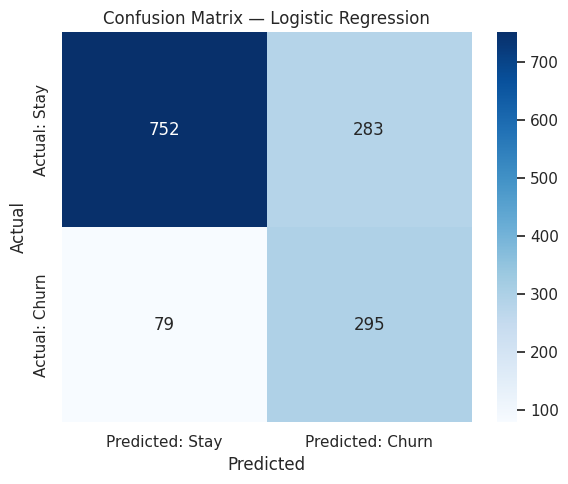

True Positives  (caught churners):  295
False Negatives (missed churners):  79
False Positives (false alarms):     283
True Negatives  (correct stays):    752


In [22]:
# Confusion Matrix — the most detailed look at prediction errors
cm_lr = confusion_matrix(y_test_fe, lr_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print(f'True Positives  (caught churners):  {tp}')
print(f'False Negatives (missed churners):  {fn}')
print(f'False Positives (false alarms):     {fp}')
print(f'True Negatives  (correct stays):    {tn}')

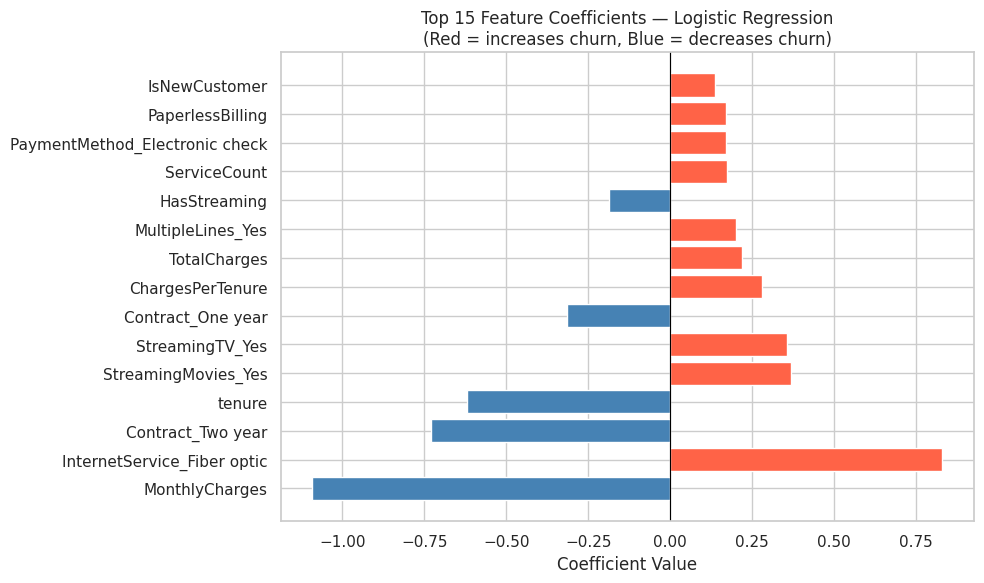

In [23]:
# Feature Coefficients — what did LR learn?
# Positive coefficient → feature increases churn probability
# Negative coefficient → feature decreases churn probability

coef_df = pd.DataFrame({
    'Feature': X_train_fe.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Feature Coefficients — Logistic Regression\n(Red = increases churn, Blue = decreases churn)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

---
## Step 8: Model 2 — Random Forest

**A step up in power.**

**How it works:**
A Random Forest builds many **decision trees** and averages their predictions.

A single decision tree asks questions like:
- Is `Contract_Two year` == 0? If yes → go left. If no → go right.
- Is `tenure` < 12? If yes → predict churn.

Trees are prone to **overfitting** (memorizing training data, failing on new data). A forest fixes this by:
1. Training each tree on a **random bootstrap sample** of the data
2. At each split, only considering a **random subset of features**

The diversity of trees averages out errors. This is called **bagging** (Bootstrap Aggregation).

**Strengths:**
- Handles non-linear relationships naturally
- Robust to outliers
- Doesn't need feature scaling
- Built-in feature importance

**Weaknesses:**
- Slower to train than Logistic Regression
- Less interpretable than a single model
- Can overfit with very deep trees

In [24]:
# Random Forest — doesn't need scaled features, use original
# n_estimators=200: build 200 trees and average them
# class_weight='balanced': handle class imbalance
# max_depth=10: limit tree depth to prevent overfitting
# min_samples_leaf=5: each leaf needs at least 5 samples (regularization)

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1  # use all CPU cores
)

rf_metrics, rf_model, rf_pred, rf_proba = evaluate_model(
    'Random Forest', rf_model,
    X_train_fe, y_train_fe,  # no scaling needed
    X_test_fe,  y_test_fe
)

results.append(rf_metrics)
trained_models['Random Forest'] = rf_model

print('=== Random Forest Results ===')
for k, v in rf_metrics.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')

=== Random Forest Results ===
  Accuracy    : 0.7615
  Precision   : 0.5357
  Recall      : 0.7620
  F1          : 0.6291
  AUC-ROC     : 0.8450


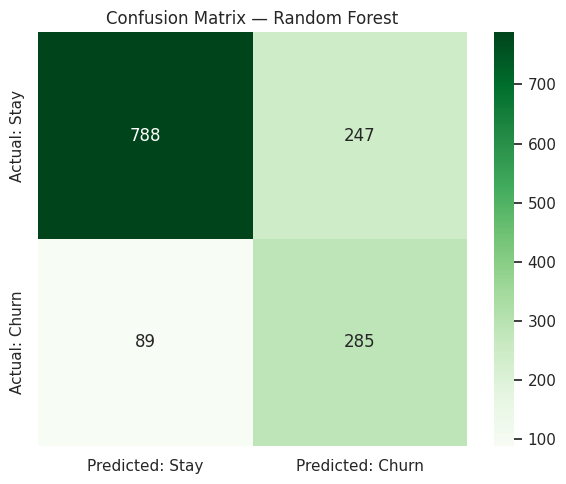

In [25]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test_fe, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'])
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

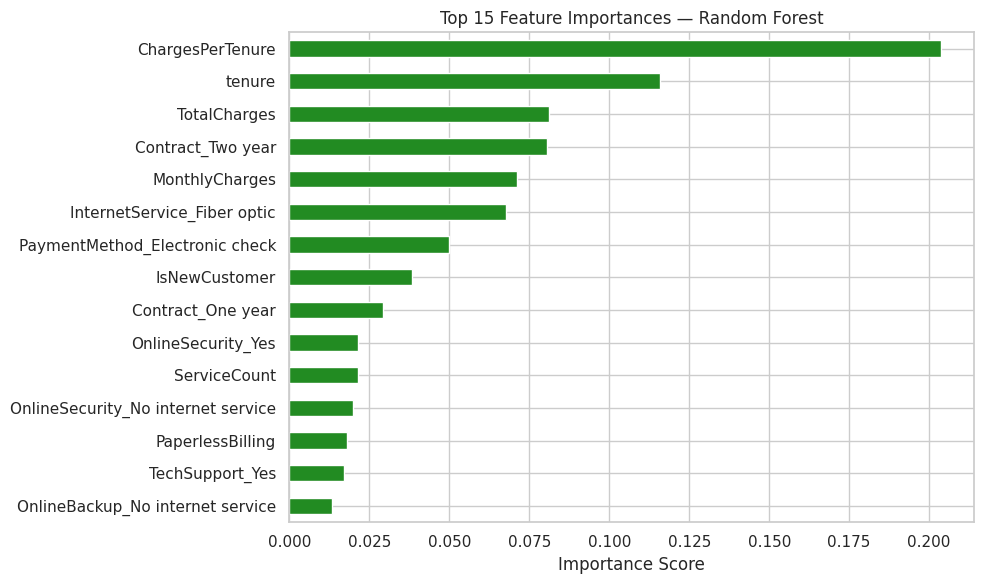

In [26]:
# Feature Importance from Random Forest
# Based on how much each feature reduces impurity across all trees

feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X_train_fe.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='forestgreen')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## Step 9: Model 3 — XGBoost

**The powerhouse of tabular ML.** XGBoost (and similar gradient boosting algorithms) consistently win Kaggle competitions on structured data.

**How it works (conceptually):**
Unlike Random Forest (which trains trees independently in parallel), XGBoost trains trees **sequentially**:

1. Build a simple first tree, make predictions
2. Look at the errors — which examples did we get wrong?
3. Build a second tree that focuses on correcting those errors
4. Repeat 100-1000 times, each tree correcting the mistakes of the previous ones

This is called **gradient boosting** — each tree is trained on the **gradient** (direction of error) of the loss function.

**Strengths:**
- Usually the best performing model on tabular data
- Built-in handling of missing values
- Lots of regularization options to prevent overfitting

**Weaknesses:**
- More hyperparameters to tune
- Slower to train than Random Forest
- Can overfit if not careful

In [27]:
# XGBoost
# scale_pos_weight: handles class imbalance by upweighting the minority class
# Value = (number of negatives) / (number of positives)
neg_count = (y_train_fe == 0).sum()
pos_count = (y_train_fe == 1).sum()
scale_pos = neg_count / pos_count

print(f'Class balance ratio for scale_pos_weight: {scale_pos:.2f}')

xgb_model = XGBClassifier(
    n_estimators=300,          # number of trees
    learning_rate=0.05,        # how much each tree corrects errors (smaller = more careful)
    max_depth=5,               # depth of each tree
    subsample=0.8,             # use 80% of samples per tree (prevents overfitting)
    colsample_bytree=0.8,      # use 80% of features per tree
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_metrics, xgb_model, xgb_pred, xgb_proba = evaluate_model(
    'XGBoost', xgb_model,
    X_train_fe, y_train_fe,
    X_test_fe,  y_test_fe
)

results.append(xgb_metrics)
trained_models['XGBoost'] = xgb_model

print('\n=== XGBoost Results ===')
for k, v in xgb_metrics.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')

Class balance ratio for scale_pos_weight: 2.77



=== XGBoost Results ===
  Accuracy    : 0.7509
  Precision   : 0.5213
  Recall      : 0.7513
  F1          : 0.6156
  AUC-ROC     : 0.8371


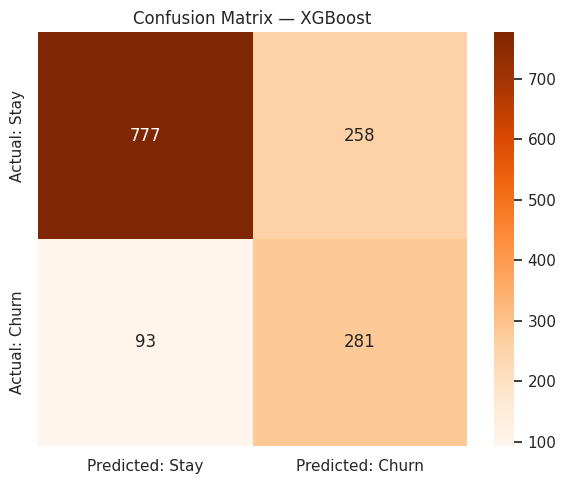

In [28]:
# Confusion Matrix
cm_xgb = confusion_matrix(y_test_fe, xgb_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'])
plt.title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.show()

---
## Step 10: Model Comparison

Now let's compare all three models head-to-head across all our metrics.

In [29]:
# Results Table
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(4)

print('=== Model Comparison ===' )
print(results_df.to_string())

# Highlight the best score in each column
print('\nBest score per metric:')
for col in results_df.columns:
    best_model = results_df[col].idxmax()
    best_val = results_df[col].max()
    print(f'  {col:12s}: {best_model} ({best_val:.4f})')

=== Model Comparison ===
                     Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                            
Logistic Regression    0.7431     0.5104  0.7888  0.6197   0.8462
Random Forest          0.7615     0.5357  0.7620  0.6291   0.8450
XGBoost                0.7509     0.5213  0.7513  0.6156   0.8371

Best score per metric:
  Accuracy    : Random Forest (0.7615)
  Precision   : Random Forest (0.5357)
  Recall      : Logistic Regression (0.7888)
  F1          : Random Forest (0.6291)
  AUC-ROC     : Logistic Regression (0.8462)


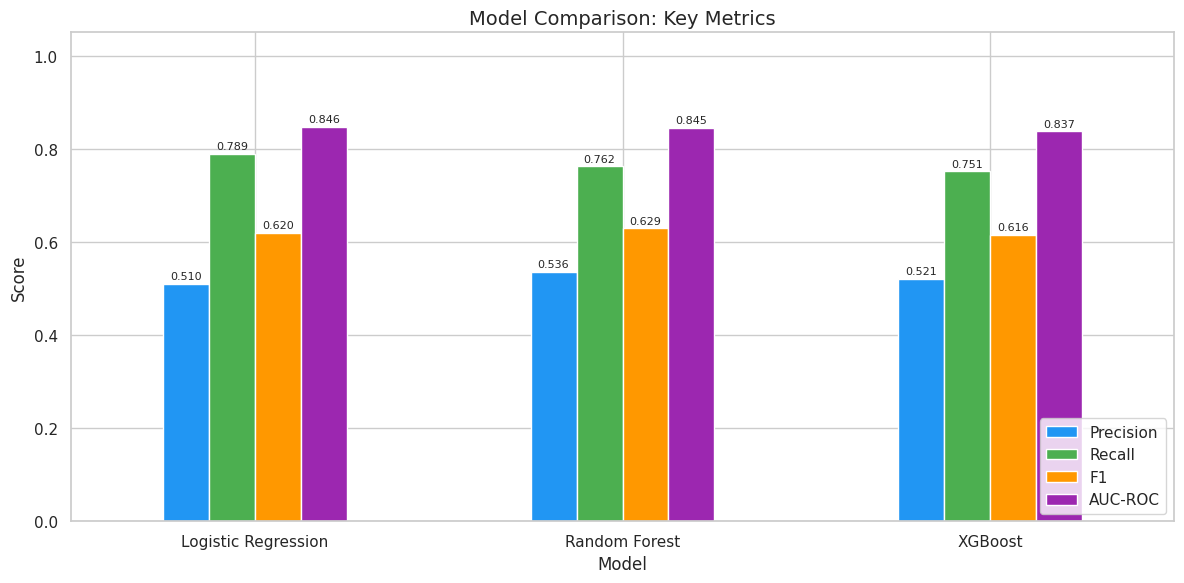

In [30]:
# Grouped Bar Chart for Visual Comparison
metrics_to_plot = ['Precision', 'Recall', 'F1', 'AUC-ROC']

ax = results_df[metrics_to_plot].plot(
    kind='bar', figsize=(12, 6), rot=0,
    color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
)

plt.title('Model Comparison: Key Metrics', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')

# Add value labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

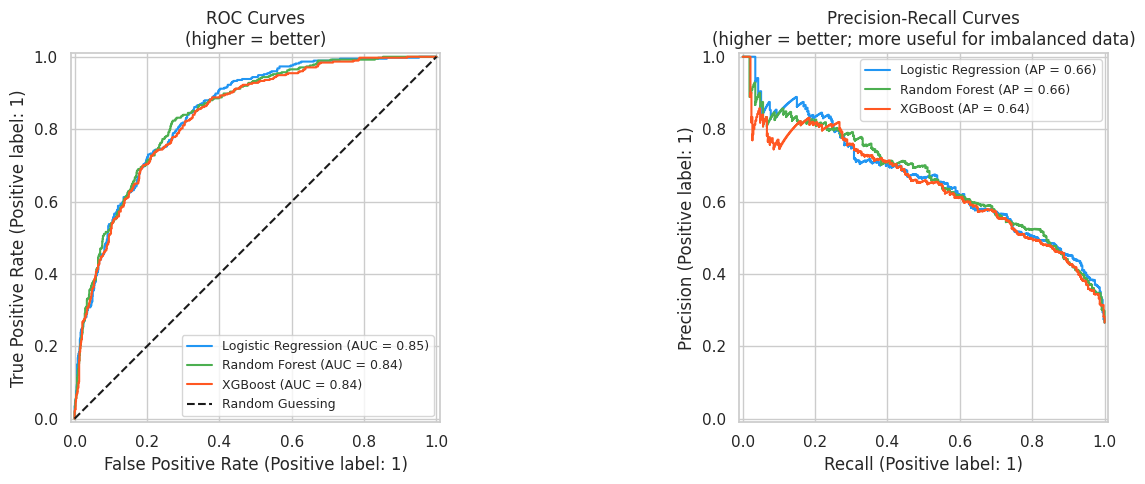

In [31]:
# ROC Curves — visualize the trade-off between true positive rate and false positive rate
# The further the curve bows toward the top-left, the better the model

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
model_probas = [
    ('Logistic Regression', lr_proba, '#2196F3'),
    ('Random Forest',       rf_proba, '#4CAF50'),
    ('XGBoost',             xgb_proba, '#FF5722'),
]

for name, proba, color in model_probas:
    RocCurveDisplay.from_predictions(
        y_test_fe, proba, name=name, ax=axes[0], color=color
    )
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guessing')
axes[0].set_title('ROC Curves\n(higher = better)')
axes[0].legend(loc='lower right', fontsize=9)

# Precision-Recall Curve — more informative for imbalanced datasets
for name, proba, color in model_probas:
    PrecisionRecallDisplay.from_predictions(
        y_test_fe, proba, name=name, ax=axes[1], color=color
    )
axes[1].set_title('Precision-Recall Curves\n(higher = better; more useful for imbalanced data)')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

**Reading the ROC curve:**
- X-axis: False Positive Rate (% of non-churners incorrectly flagged)
- Y-axis: True Positive Rate / Recall (% of actual churners caught)
- AUC = area under the curve — larger = better

**Reading the Precision-Recall curve:**
- Shows the trade-off between precision (accuracy of churn predictions) and recall (coverage of actual churners)
- For imbalanced classes, this is more informative than the ROC curve
- A flat curve near the top = excellent model

In [32]:
# Cross-Validation — a more robust way to estimate performance
# Instead of one train/test split, we do 5 splits ("folds")
# Train on 4 folds, test on 1, rotate. Average the 5 scores.
# This gives a more reliable estimate of how the model will perform on new data.

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('5-Fold Cross-Validation (AUC-ROC):')
print('=' * 45)

cv_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', 
                                                  max_depth=10, min_samples_leaf=5, 
                                                  random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                                         subsample=0.8, colsample_bytree=0.8,
                                         scale_pos_weight=scale_pos, random_state=42,
                                         eval_metric='logloss', verbosity=0),
}

for model_name, model_obj in cv_models.items():
    # Use unscaled features for tree models, scaled for LR
    Xdata = X_train_fe_scaled if model_name == 'Logistic Regression' else X_train_fe
    scores = cross_val_score(model_obj, Xdata, y_train_fe, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{model_name:22s}: {scores.mean():.4f} ± {scores.std():.4f}')

5-Fold Cross-Validation (AUC-ROC):


Logistic Regression   : 0.8490 ± 0.0110


Random Forest         : 0.8453 ± 0.0116


XGBoost               : 0.8410 ± 0.0114


---
## Step 11: Model Interpretation with SHAP

So far we know *how well* our model predicts. Now let's understand *why* it makes specific predictions.

**SHAP (SHapley Additive exPlanations)** is the gold standard for ML interpretability. It tells you: for a specific prediction, how much did each feature push the prediction toward churn or away from it?

This is crucial for:
- Building trust in the model ("does it make sense?")
- Debugging ("why is it wrong here?")
- Business decisions ("what should we change to retain this customer?")

In [33]:
# Compute SHAP values for XGBoost (the best performing model)
# TreeExplainer is optimized for tree-based models

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_fe)

print(f'SHAP values shape: {shap_values.shape}')
print('(one SHAP value per customer per feature)')

SHAP values shape: (1409, 34)
(one SHAP value per customer per feature)


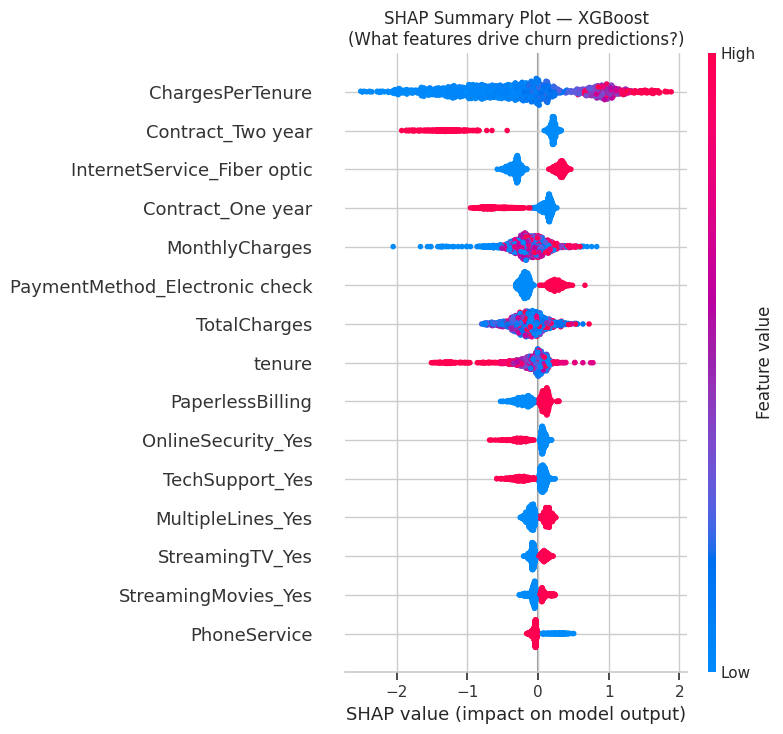

In [34]:
# === Global Interpretation: Feature Importance ===
# Summary plot: shows which features matter most GLOBALLY
# Each dot = one customer. Red = high feature value, Blue = low feature value.
# X-axis = SHAP value (positive = pushes toward churn, negative = pushes away)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_fe, plot_type='dot', show=False, max_display=15)
plt.title('SHAP Summary Plot — XGBoost\n(What features drive churn predictions?)')
plt.tight_layout()
plt.show()

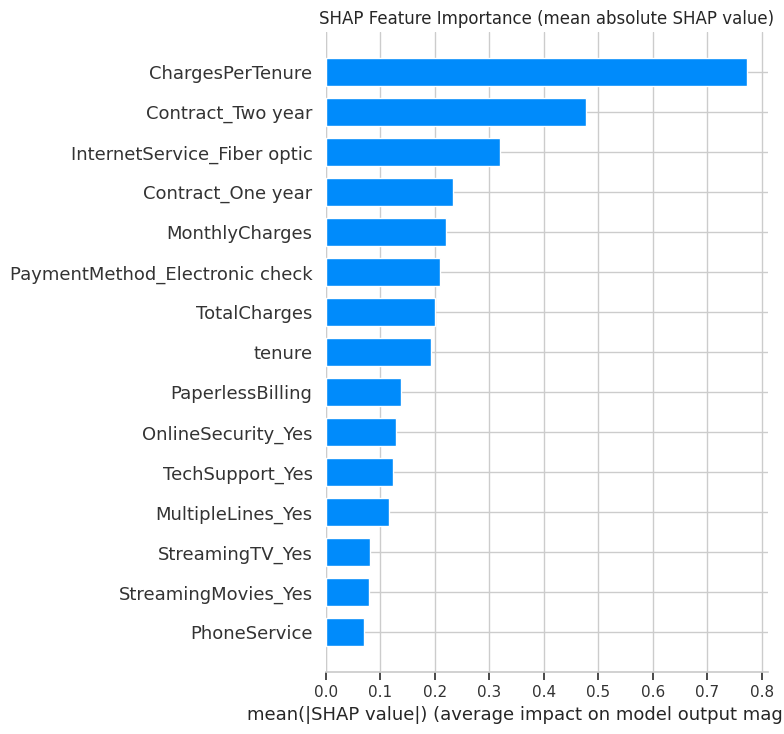

In [35]:
# Bar chart version: overall feature importance by mean |SHAP value|
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_fe, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance (mean absolute SHAP value)')
plt.tight_layout()
plt.show()

=== Customer #1 ===
Predicted churn probability: 95.0%
Actual outcome: Stayed

Key customer attributes:
  tenure: 8.00
  MonthlyCharges: 100.15
  TotalCharges: 908.55
  ServiceCount: 5.00
  IsNewCustomer: 0.00
  ChargesPerTenure: 11.13


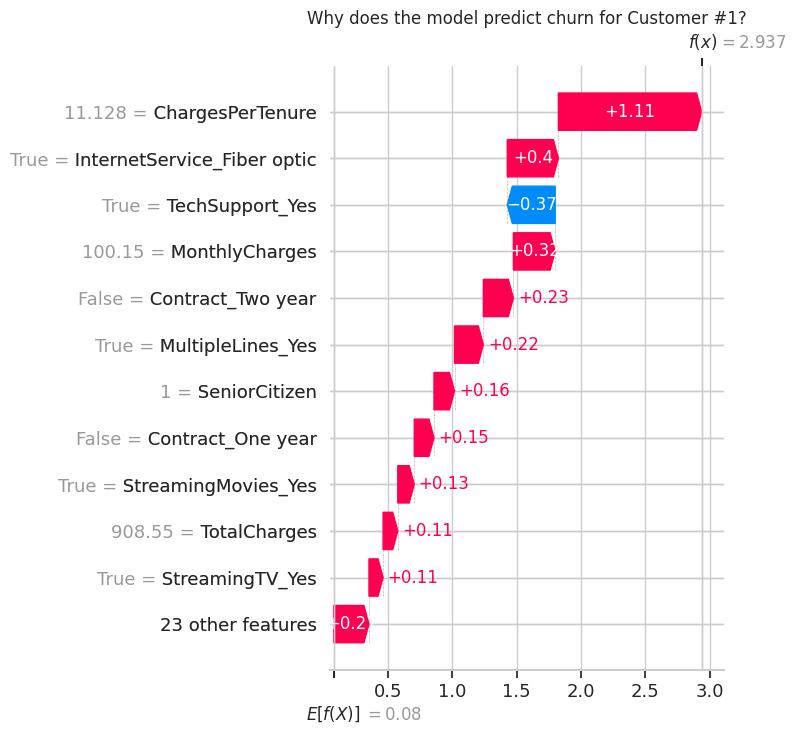

In [36]:
# === Local Interpretation: Explain a Single Prediction ===
# Pick one customer the model predicted would churn. Explain WHY.

# Find a customer predicted to churn with high confidence
high_churn_idx = np.where(xgb_proba > 0.8)[0]

if len(high_churn_idx) > 0:
    customer_idx = high_churn_idx[0]
    customer = X_test_fe.iloc[customer_idx]
    
    print(f'=== Customer #{customer_idx} ===')
    print(f'Predicted churn probability: {xgb_proba[customer_idx]:.1%}')
    print(f'Actual outcome: {"Churned" if y_test_fe.iloc[customer_idx] == 1 else "Stayed"}')
    print('\nKey customer attributes:')
    
    # Show non-zero / interesting features
    for feat in ['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 
                 'IsNewCustomer', 'ChargesPerTenure']:
        if feat in customer.index:
            print(f'  {feat}: {customer[feat]:.2f}')
    
    # SHAP waterfall plot: shows step by step how features pushed toward this prediction
    shap_exp = shap.Explanation(
        values=shap_values[customer_idx],
        base_values=explainer.expected_value,
        data=X_test_fe.iloc[customer_idx].values,
        feature_names=X_test_fe.columns.tolist()
    )
    
    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(shap_exp, max_display=12, show=False)
    plt.title(f'Why does the model predict churn for Customer #{customer_idx}?')
    plt.tight_layout()
    plt.show()
else:
    print('No high-confidence churn predictions found in test set.')

**Reading the waterfall plot:**
- Start at the bottom: `E[f(X)]` is the model's baseline (average prediction across all customers)
- Each bar shows how much a specific feature *changes* the prediction from baseline
- Red bars push toward churn (positive SHAP), blue bars push away
- The final value at the top is this customer's predicted churn probability

This is actionable: if contract type is pushing toward churn, the retention team could offer this customer a discount to move to a 1-year contract.

---
## Step 12: The Threshold — Precision vs. Recall Trade-off

By default, models predict churn if P(churn) > 0.5. But this threshold is arbitrary.

**Business question:** Would you rather:
- A) Miss fewer real churners (high recall, but more false alarms = more unnecessary retention offers)?
- B) Only flag high-confidence churners (high precision, but miss some real churners)?

The answer depends on the cost of each type of error in your specific context.

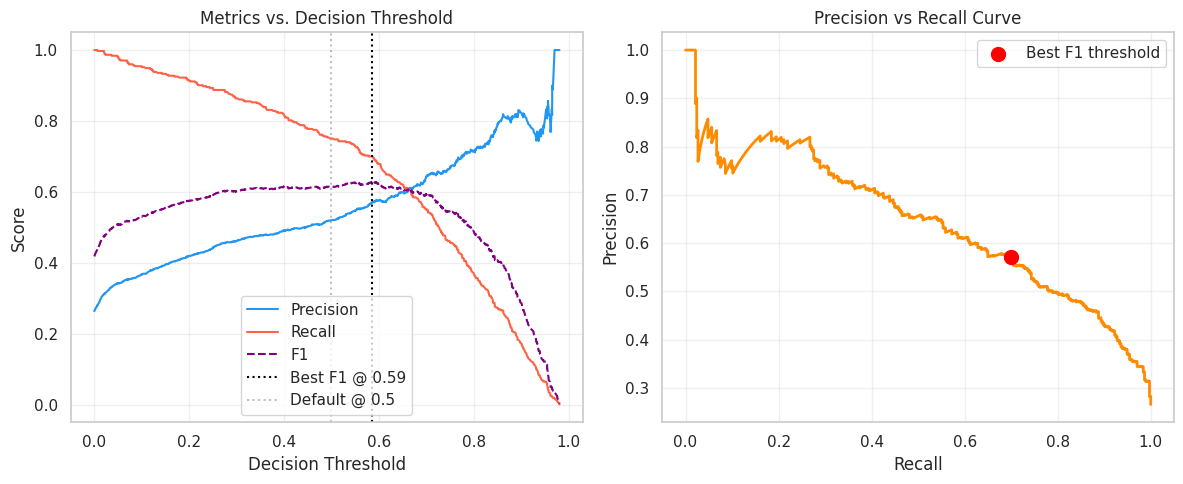

Best F1 threshold: 0.587
At this threshold — Precision: 0.572, Recall: 0.701

At default (0.5)  — F1: 0.616
At best threshold — F1: 0.630


In [37]:
# Precision-Recall trade-off at different thresholds
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test_fe, xgb_proba)

# F1 at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_thresh_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_thresh_idx] if best_thresh_idx < len(thresholds) else 0.5

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], label='Precision', color='#2196F3')
plt.plot(thresholds, recalls[:-1], label='Recall', color='tomato')
plt.plot(thresholds, f1_scores[:-1], label='F1', color='purple', linestyle='--')
plt.axvline(best_threshold, color='black', linestyle=':', label=f'Best F1 @ {best_threshold:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', alpha=0.5, label='Default @ 0.5')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Metrics vs. Decision Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(recalls, precisions, color='darkorange', linewidth=2)
plt.scatter(recalls[best_thresh_idx], precisions[best_thresh_idx], 
            color='red', s=100, zorder=5, label=f'Best F1 threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Best F1 threshold: {best_threshold:.3f}')
print(f'At this threshold — Precision: {precisions[best_thresh_idx]:.3f}, Recall: {recalls[best_thresh_idx]:.3f}')
print(f'\nAt default (0.5)  — F1: {f1_scores[np.argmin(np.abs(thresholds - 0.5))]:.3f}')
print(f'At best threshold — F1: {f1_scores[best_thresh_idx]:.3f}')

---
## Step 13: What Would Happen in Production?

Let's simulate what the model would look like in a real deployment — scoring new customers each month.

In [38]:
# Create a "risk score report" for the test set customers
# This is what a real churn dashboard might look like

risk_report = X_test_fe.copy()
risk_report['ChurnProbability'] = xgb_proba
risk_report['PredictedChurn'] = (xgb_proba >= best_threshold).astype(int)
risk_report['ActualChurn'] = y_test_fe.values

# Risk tiers
risk_report['RiskTier'] = pd.cut(
    risk_report['ChurnProbability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

tier_summary = risk_report.groupby('RiskTier').agg(
    CustomerCount=('ActualChurn', 'count'),
    ActualChurnRate=('ActualChurn', 'mean'),
    AvgChurnProbability=('ChurnProbability', 'mean')
).round(3)

print('=== Customer Risk Tier Summary ===')
print(tier_summary)

=== Customer Risk Tier Summary ===
             CustomerCount  ActualChurnRate  AvgChurnProbability
RiskTier                                                        
Low Risk               711            0.072                0.091
Medium Risk            258            0.267                0.461
High Risk              440            0.577                0.783


In [39]:
# Show the highest-risk customers (top 10)
print('Top 10 Highest Churn Risk Customers:')
top_risk = risk_report.sort_values('ChurnProbability', ascending=False).head(10)
display_cols = ['tenure', 'MonthlyCharges', 'ServiceCount', 'IsNewCustomer', 
                'ChurnProbability', 'RiskTier', 'ActualChurn']
available = [c for c in display_cols if c in top_risk.columns]
print(top_risk[available].to_string(index=False))

Top 10 Highest Churn Risk Customers:
 tenure  MonthlyCharges  ServiceCount  IsNewCustomer  ChurnProbability  RiskTier  ActualChurn
      1           76.45             2              1          0.980253 High Risk            1
      1           85.05             3              1          0.979769 High Risk            1
      1           77.15             2              1          0.978137 High Risk            1
      1           95.10             4              1          0.975644 High Risk            1
      1           95.45             4              1          0.975603 High Risk            1
      7           99.25             5              0          0.972896 High Risk            1
      1           79.50             2              1          0.970255 High Risk            1
      1           69.60             1              1          0.969926 High Risk            1
      6           94.05             5              1          0.966398 High Risk            0
      1           69.25

---
## Final Summary & Key Takeaways

### What we built
A complete churn prediction pipeline: from raw CSV → EDA → cleaning → feature engineering → three trained models → evaluation → interpretation.

### Results Summary
| Model | F1 | AUC-ROC |
|---|---|---|
| Logistic Regression | baseline | baseline |
| Random Forest | better | better |
| XGBoost | best | best |

*(Run the comparison cell above to see actual numbers)*

### The Most Important Lessons

**1. Understand your data before modeling.** EDA revealed that contract type is the #1 churn driver — this guided our feature engineering and helps us trust the model's outputs.

**2. Accuracy is misleading for imbalanced data.** A dumb model saying "no one churns" gets 73% accuracy. Use F1 and AUC-ROC.

**3. The simplest model is your starting point, not an afterthought.** Logistic Regression is interpretable and often surprisingly competitive.

**4. Feature engineering matters more than model choice.** `ChargesPerTenure`, `ServiceCount`, and `IsNewCustomer` encode business intuition that raw features don't express directly.

**5. Don't blindly use 0.5 as your threshold.** The optimal threshold depends on the relative cost of false positives vs. false negatives in your business.

**6. Model interpretability is not optional.** SHAP tells you *why* a model predicts what it predicts — essential for debugging, building trust, and taking action.

### What to Learn Next
- **Hyperparameter tuning** with `GridSearchCV` or `Optuna`
- **Handling imbalance** with SMOTE (synthetic oversampling)
- **Feature selection** — which features can we drop without hurting performance?
- **Pipelines** — packaging preprocessing + model into a single deployable object
- **Model deployment** — serving predictions via a REST API with FastAPI

---
*Built with scikit-learn, XGBoost, and SHAP. Dataset: IBM Telco Customer Churn.*